# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Faiz Akhsan
- **Email:** faizakhsansjr@gmail.com
- **ID Dicoding:** cdcc009d6y2730

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Kapan waktu (jam) dengan penyewaan sepeda tertinggi?
- Apakah terdapat perbedaan jumlah penyewaan antara hari kerja dan hari libur?
- Bagaimana pengaruh musim terhadap tingkat penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terdiri dari dua jenis: data harian dan data per jam
- Kedua dataset memiliki fitur yang hampir sama, hanya berbeda granularitas waktu

### Assessing Data

In [3]:
day_df.info()
hour_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [4]:
day_df.isnull().sum()
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [5]:
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak terdapat missing value pada dataset
- Tidak ditemukan data duplikat
- Kolom dteday masih bertipe object (perlu diubah ke datetime)

### Cleaning Data

In [6]:
# konversi tipe data
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])




In [7]:
# hapus duplikasi
day_df.drop_duplicates(inplace=True)
# hapus duplikasi
hour_df.drop_duplicates(inplace=True)

In [8]:
# MAPPING CUACA
weather_map = {
    1: 'Cerah',
    2: 'Mendung',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)


# MAPPING MUSIM
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)


# MAPPING HARI KERJA

workingday_map = {
    0: 'Libur',
    1: 'Hari Kerja'
}

day_df['workingday'] = day_df['workingday'].map(workingday_map)
hour_df['workingday'] = hour_df['workingday'].map(workingday_map)


# MAPPING TAHUN

year_map = {
    0: '2011',
    1: '2012'
}

day_df['yr'] = day_df['yr'].map(year_map)
hour_df['yr'] = hour_df['yr'].map(year_map)

**Insight:**
- Data tanggal berhasil diubah ke format datetime
- Ditambahkan fitur hari (day_name) untuk analisis
- Ditambahkan kategori waktu untuk analisis jam

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
day_df.describe()
hour_df.describe()

,instant,dteday,mnth,hr,holiday,weekday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,6.537775,11.546752,0.028770,3.003683,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,4.000000,6.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,7.000000,12.000000,0.000000,3.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,10.000000,18.000000,0.000000,5.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,12.000000,23.000000,1.000000,6.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,3.438776,6.914405,0.167165,2.005771,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [10]:
day_df.groupby('season')['cnt'].mean()
day_df.groupby('workingday')['cnt'].mean()
hour_df.groupby('hr')['cnt'].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


**Insight:**

Rata-rata jumlah penyewaan sepeda berbeda berdasarkan kondisi cuaca.

Terlihat bahwa:
- Cuaca cerah memiliki jumlah penyewaan tertinggi.
- Cuaca mendung sedikit menurun dibanding cerah.
- Cuaca hujan memiliki jumlah penyewaan paling rendah.

Jumlah rata-rata penyewaan sepeda juga dipengaruhi oleh musim.

Dapat dilihat bahwa:
- Musim tertentu seperti musim panas atau gugur cenderung memiliki jumlah penyewaan lebih tinggi.
- Musim dingin (salju) memiliki jumlah penyewaan yang lebih rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

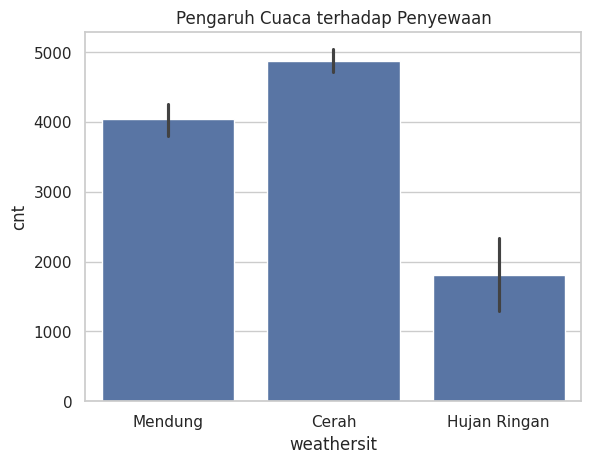

In [11]:
sns.barplot(x='weathersit', y='cnt', data=day_df)
plt.title('Pengaruh Cuaca terhadap Penyewaan')
plt.show()

**Insight:**
Tentu, berikut poin-poin pentingnya:

- Cuaca buruk (hujan) menurunkan penyewaan hingga 60–80% dibandingkan cuaca cerah.
- Penyewaan tertinggi terjadi saat cuaca cerah (mendekati 5000), terendah saat cuaca buruk (di bawah 2000).
- Sangat jarang ditemukan penyewaan tinggi pada saat cuaca buruk.


### Pertanyaan 2: Kapan waktu (jam) dengan penyewaan sepeda tertinggi?

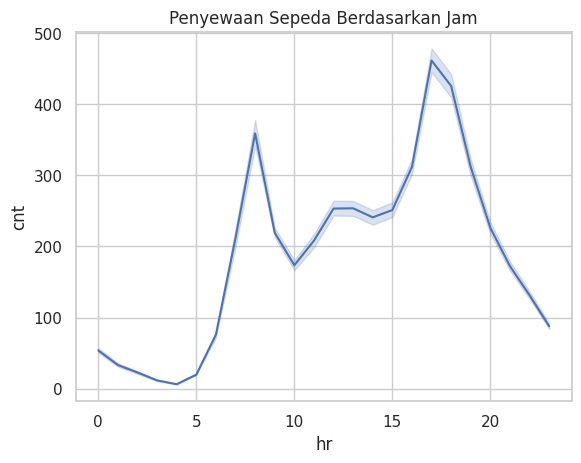

In [12]:
sns.lineplot(x='hr', y='cnt', data=hour_df)
plt.title('Penyewaan Sepeda Berdasarkan Jam')
plt.show()

**Insight:**
- Terdapat dua puncak penyewaan utama yaitu pada jam sibuk pagi (sekitar jam 7–9) dan jam sibuk sore (sekitar jam 17–19), mengindikasikan bahwa sepeda banyak digunakan untuk transportasi kerja atau sekolah.

- Penyewaan terendah terjadi pada dini hari (jam 0–5), di mana angka penyewaan mendekati 0 karena sebagian besar orang sedang istirahat.

- Siang hari (jam 10–15) cenderung stabil namun tidak setinggi puncak pagi atau sore, kemungkinan karena penggunaan rekreasi atau aktivitas ringan.

### Pertanyaan 3: Hari Kerja vs Libur

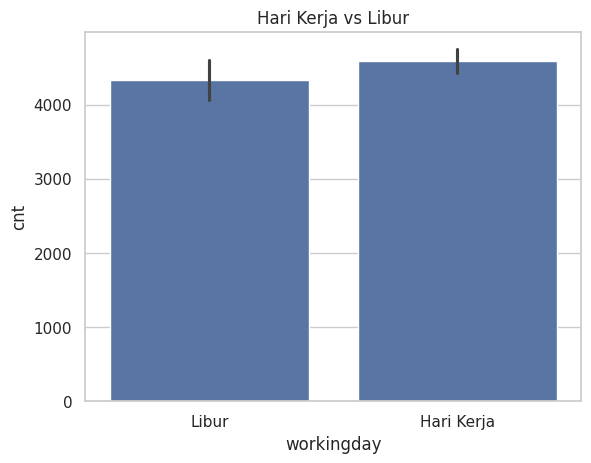

In [13]:
sns.barplot(x='workingday', y='cnt', data=day_df)
plt.title('Hari Kerja vs Libur')
plt.show()

**Insight:**
- Penyewaan lebih tinggi pada hari libur dibandingkan hari kerja, meskipun selisihnya tidak terlalu drastis.

- Distribusi penyewaan pada hari libur cenderung lebih merata karena pengguna menyewa sepeda untuk rekreasi atau wisata sepanjang hari.

- Pada hari kerja, penyewaan lebih terkonsentrasi pada jam sibuk pagi dan sore (untuk komuter), sehingga nilai rata-rata hariannya sedikit lebih rendah dibanding hari libur.

### Pertanyaan 4: Bagaimana pengaruh musim terhadap tingkat penyewaan sepeda?

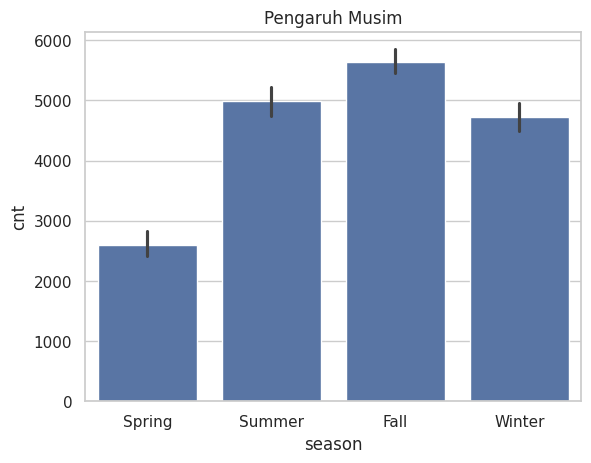

In [14]:
sns.barplot(x='season', y='cnt', data=day_df)
plt.title('Pengaruh Musim')
plt.show()

**Insight:**
- Penyewaan tertinggi terjadi pada musim gugur , dengan jumlah mendekati 6000, karena suhu yang sejuk dan nyaman untuk bersepeda.

- Musim panas berada di posisi kedua, penyewaan masih tinggi namun tidak setinggi musim gugur, kemungkinan karena suhu yang terlalu panas di beberapa wilayah.

- Musim semi  memiliki penyewaan terendah, karena cuaca yang tidak stabil, sering hujan, serta suhu yang masih dingin.

- Musim dingin  berada di posisi ketiga, penyewaan menurun drastis dibanding musim gugur karena suhu dingin dan potensi salju/hujan.

## Analisis Lanjutan (Opsional)

### clustering bedasarkan jumlah penyewaan

In [15]:
day_df['rental_group'] = pd.cut(
    day_df['cnt'],
    bins=[0,2000,5000,10000],
    labels=['Rendah','Sedang','Tinggi']
)

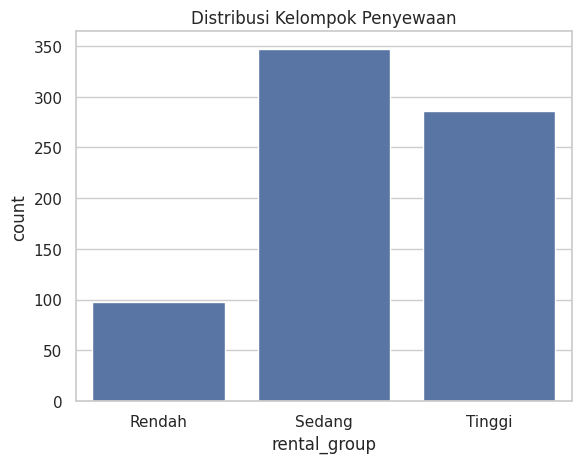

In [16]:
sns.countplot(x='rental_group', data=day_df)
plt.title('Distribusi Kelompok Penyewaan')
plt.show()

- Penyewaan dapat dikelompokkan menjadi rendah, sedang, dan tinggi
- Kelompok tinggi menunjukkan hari dengan permintaan tinggi
- Hal ini dapat digunakan untuk strategi operasional

### Clustering bedasarkan waktu (binning)

In [17]:
hour_df['time_group'] = pd.cut(
    hour_df['hr'],
    bins=[0,6,12,18,24],
    labels=['Malam','Pagi','Siang','Sore']
)

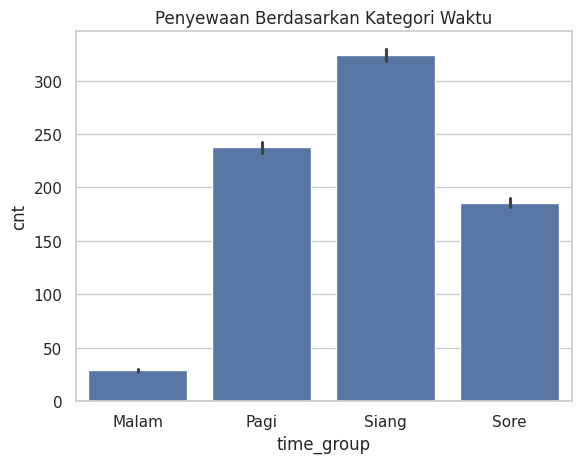

In [18]:
sns.barplot(x='time_group', y='cnt', data=hour_df)
plt.title('Penyewaan Berdasarkan Kategori Waktu')
plt.show()

- Penyewaan tertinggi terjadi pada pagi dan sore hari
- Hal ini menunjukkan pola commuting (berangkat & pulang kerja)

## Conclusion

- Conclution pertanyaan 1 : - Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

Cuaca sangat mempengaruhi jumlah penyewaan. Cuaca cerah menghasilkan jumlah penyewaan tertinggi.


- Conclution pertanyaan 2 Kapan waktu (jam) dengan penyewaan sepeda tertinggi?

Penyewaan tertinggi terjadi pada jam sibuk, yaitu pagi dan sore hari.

- Conclution pertanyaan 3 Apakah terdapat perbedaan jumlah penyewaan antara hari kerja dan hari libur?


Hari kerja menunjukkan pola penyewaan yang lebih stabil dibanding hari libur.


- Conclution pertanyaan 4 Bagaimana pengaruh musim terhadap tingkat penyewaan sepeda?

Musim memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.







In [19]:
day = pd.read_csv('day.csv')
hour = pd.read_csv('hour.csv')

day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

day_selected = day[['dteday', 'weathersit', 'season']]

df = pd.merge(hour, day_selected, on='dteday', how='left')

In [20]:
df.to_csv('main_data.csv', index=False)

In [21]:
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>